# How does a PydanticAI agent respond to a sudden +200bps rate shock?

**PydanticAI** is the agent framework. **Tradefloor** is the controlled
environment that measures what the agent does when the world changes.

A historical dataset gives you one realized history. There is no second 2022
in which rates held still, so you cannot ask it what this agent would have
done otherwise.

This notebook creates two worlds that share the same history up to a
checkpoint, changes one number in one of them, and compares what the same
agent does next.

This is an **agent-evaluation** experiment. One seed cannot say which arm was
the better investor. It can say exactly what the same agent, holding the same
book, did differently when one number changed.

It is the same experiment as
[`finrobot/rate_shock.ipynb`](finrobot/rate_shock.ipynb), run through a
different framework, so the two can be read side by side.

## 1. The experiment

```
                    SAME HISTORY
                         |
                   PydanticAI agent
                         |
                    CHECKPOINT
                         |
                +--------+--------+
                |                 |
             CONTROL          +200BPS
                |                 |
          PydanticAI        PydanticAI
                |                 |
                +--------+--------+
                         |
                      COMPARE
```

Everything before the checkpoint is shared, and byte-identical rather than
merely similar: the same prices, the same order book, the same generator
position, the same portfolio, the same agent. So everything differing
afterwards descends from the one field that changed.

### Live calls and replay

Tradefloor's market is deterministic and an LLM behind an API is not, so two
live runs give two different agents. **This notebook replays a recorded run
by default**, and the market re-executes for real either way -- only the
agent's answers come from the recording, keyed by the exact observation it
was sent.

Replay needs no API key, no network, and **no PydanticAI installed**. That
last one is deliberate: the point of shipping the recording is that this page
is readable by someone who has never installed the framework.

A live run needs three things, and the opt-in comes first:
`TRADEFLOOR_LIVE_EXAMPLES=1`, a provider key in `ANTHROPIC_API_KEY`, and
`pip install "tradefloor[pydantic-ai]"`. **A credential existing in your
environment is not consent to spend it** — without the opt-in, anyone with a
key exported who ran the slow test suite would re-execute every live notebook
and pay for it, having asked for neither, and the replay-identity cell at the
bottom would then honestly read `False`, so the surprise bill would arrive
dressed as a test failure. The mode cell below names whichever of the three
is missing, and a live run prints what it is about to cost before it costs
it.

In [1]:
import json
import os
import sys
from pathlib import Path

import tradefloor as tf
from tradefloor.counterfactual import World, agree, compare
from tradefloor.integrations.common import Transcript

# The production adapter. This notebook implements none of the integration:
# `tradefloor/integrations/pydantic_ai.py` is the source of truth, and this
# is the same object the shipped example and the test suite use.
from tradefloor.integrations.pydantic_ai import MANDATE, MANDATE_VERSION

# The experiment's constants come from the example script beside this
# notebook, for the same reason. One definition, so the notebook and the
# script cannot drift into describing two different experiments.
sys.path.insert(0, str(Path.cwd()))
import rate_shock as experiment

# Live requires an EXPLICIT opt-in on top of the key and the SDK. A
# credential in the environment is not consent to spend it, so replay is
# the default even when a live run is possible.
LIVE = experiment.can_run_live()
print(f"tradefloor  {tf.__version__}")
print(f"mode        {'live, calling ' + experiment.LIVE_MODEL if LIVE else 'replay'}")
if not LIVE:
    missing = []
    if not os.environ.get(experiment.LIVE_OPT_IN_VAR):
        missing.append(f"{experiment.LIVE_OPT_IN_VAR}=1")
    if not experiment.have_live_key():
        missing.append(experiment.LIVE_KEY_VAR)
    if not experiment.have_framework():
        missing.append('pip install "tradefloor[pydantic-ai]"')
    print(f"            live would need {', '.join(missing)}")

tradefloor  0.8.5
mode        replay
            live would need TRADEFLOOR_LIVE_EXAMPLES=1, ANTHROPIC_API_KEY


## 2. The market

Four synthetic companies. Nothing about them is real -- the tickers, the
sectors and every fundamental are generated -- so nothing the model knows
about a listed company applies here, and it cannot recognise its way to an
answer.

They differ in the one property that decides rate sensitivity in this model:
revenue growth is the duration term in the valuation, so a rate move is worth
more to a fast-growing name than to a slow one. That is what makes the shock
something an agent could reason about rather than a uniform repricing.

In [2]:
roster = experiment.universe()

rows = [(i.ticker, i.sector, f"${i.initial_price:,.2f}",
         f"{i.revenue_growth:.0%}", f"{i.avg_volume:,.0f}")
        for i in roster]
width = [max(len(str(r[c])) for r in rows + [("ticker", "sector", "price",
                                              "growth", "avg volume")])
         for c in range(5)]
header = ("ticker", "sector", "price", "growth", "avg volume")
print("  ".join(h.ljust(w) for h, w in zip(header, width)))
print("  ".join("-" * w for w in width))
for r in rows:
    print("  ".join(str(c).ljust(w) for c, w in zip(r, width)))
print(f"\nseed {experiment.SEED}, ${experiment.CASH:,.0f} of cash, "
      f"pinned at {experiment.POLICY_RATE:.2%} policy / "
      f"{experiment.DISCOUNT_RATE:.2%} discount")

ticker    sector              price    growth  avg volume
--------  ------------------  -------  ------  ----------
TECH_A    technology          $140.00  30%     5,000,000 
TECH_B    technology          $95.00   22%     5,000,000 
BANK_A    financial_services  $60.00   5%      5,000,000 
STAPLE_A  consumer_staples    $48.00   2%      5,000,000 

seed 4242, $10,000,000 of cash, pinned at 4.00% policy / 5.50% discount


## 3. Attaching a real PydanticAI agent

The adapter runs an agent **you** built. It does not build one, and it does
not ask you to rebuild one:

```python
pm = Agent("anthropic:claude-opus-5", deps_type=Desk,
           instructions="You are a systematic portfolio manager.")

@pm.tool
def house_gross_exposure_limit(ctx: RunContext[Desk]) -> float:
    return ctx.deps.gross_exposure_limit

agent = PydanticAIAdapter(pm, deps=Desk("systematic", 1.5))
```

Your `deps_type`, your tools, your `RunContext` usage, your instructions and
your toolsets all keep working, because the adapter changes none of them.

### Who owns what

| PydanticAI owns | Tradefloor owns |
|---|---|
| interpretation | the market and the macro path |
| the portfolio decision | execution, the book, fills, accounting |
| a one-line rationale | checkpoints, forks, interventions, comparison |

The agent never touches engine state. It returns a validated
`DecisionModel`; the adapter checks every action against the listed universe
and the supported sides, refuses anything it cannot execute, and hands share
deltas to the same execution path every other agent uses.

### The one thing you give up

The observation arrives **in the prompt**, as JSON. Your tools cannot query
it: there is no `ctx.deps.observation`. That is not an oversight. PydanticAI
has exactly one dependency slot -- `run(deps=...)`, read by every tool
through `RunContext.deps` -- and no runtime type check on it, so an adapter
that put its own payload there would hand your tools an object of the wrong
type and they would fail on the attribute access. There is no second channel.
So the adapter carries nothing there and passes yours through untouched.

### What it is never shown

`Observation` carries `.engine`, and the engine knows the answer key: fair
value, the nine-way factor attribution of every price move, each company's
mispricing, and the macro path the run has not reached yet. The observation
mapping is an **allowlist, written out field by field**.
`tests/test_integrations.py` proves the boundary against an engine that
raises if the forbidden surface is touched, and `tests/test_pydantic_ai.py`
runs the same check through this adapter's real framework path.

In [3]:
if LIVE:
    recorder = Transcript()
    agent = experiment.live_agent(recorder=recorder, arm="shared")
    agent.recorder.meta.update(agent.provenance())
    # Say what is about to be spent BEFORE spending it. The run cells below
    # are where the calls happen.
    calls = experiment.SHARED_DAYS + 2 * experiment.BRANCH_DAYS
    print(f"live: {experiment.LIVE_MODEL}")
    print(f"the cells below will make {calls} calls -- "
          f"{experiment.SHARED_DAYS} shared, then "
          f"{experiment.BRANCH_DAYS} per arm -- up to "
          f"{experiment.LIVE_MAX_TOKENS} output tokens each")
else:
    transcript = Transcript.load(experiment.FIXTURE)
    agent = experiment.replay_agent(transcript=transcript, arm="shared")
    print(f"replaying {len(transcript)} recorded interactions from")
    print(f"  {experiment.FIXTURE.name}\n")
    for field in ("framework", "framework_version", "entry_point", "model",
                  "mode", "instructions_version", "instructions_digest",
                  "decision_every_steps", "max_participation",
                  "decision_schema_version"):
        print(f"  {field:<24} {transcript.meta.get(field)}")

agent

replaying 15 recorded interactions from
  rate-shock.json

  framework                pydantic-ai
  framework_version        2.49.0
  entry_point              pydantic_ai.Agent.run
  model                    anthropic:claude-opus-5
  mode                     live
  instructions_version     2
  instructions_digest      631eee55bf7b9e99
  decision_every_steps     6
  max_participation        0.02
  decision_schema_version  1


PydanticAIAdapter(mode='replay', arm='shared', every=6, decisions=0)

## 4. The mandate

Identical in both arms. It says what the agent is for and what the market can
execute. It says nothing about what is coming: the question the experiment
asks is whether the agent infers a changed world from the observation, and an
arm told it was the shocked arm would be answering something else.

It does not restate the answer *shape*. Tradefloor's shared decision model is
bound as the run's `output_type`, so the field names, the side enum and the
non-negative share count reach the model as schema, where they are enforced
rather than requested.

In [4]:
print(f"mandate version {MANDATE_VERSION}\n")
print(MANDATE)

mandate version 2

You are managing a portfolio inside a simulated financial market.

The message is the entire observable state, as JSON. Use nothing else. You have no other data source and no browsing. The tickers are synthetic and are not real listed companies, so anything you know about real securities does not apply here.

Seek attractive risk-adjusted returns while controlling downside risk. You may buy, sell, resize or maintain positions. You are not required to trade: an empty action list means change nothing, and is a valid answer.

Every order is a market sweep of the live book. There are no limit prices and no order types. Quantities are SHARES, always positive -- the side carries the direction.

Two separate limits bind your orders, and you must respect BOTH.

`max_order_shares` on each asset is the participation cap: the most this MARKET will absorb from you in that asset in one step. `portfolio.buying_power` is the funding cap: the additional gross notional this BOOK can 

## 5. Two size limits, and why both are stated

This is the part of the environment most likely to catch an agent out, so the
observation states it twice and the mandate says it in words.

* **`max_order_shares`** is the *participation* cap, per asset: what this
  market can absorb from one order before the order becomes the price.
* **`portfolio.buying_power`** is the *funding* cap, shared across every
  asset: what this book can hold before the leverage limit refuses the trade.

The funding cap is usually the binding one, and an order that exceeds it is
**refused, not reduced** -- it buys nothing and costs the decision. Sizing
each name to its own participation cap therefore asks for far more than the
book can fund.

That is not hypothetical. Four independent agents -- two frontier models and
two documentation examples -- sized to the participation cap alone, were
refused at a limit the payload did not mention, and scored zero trades. The
payload gained `buying_power` and `max_leverage` because of it, and version 2
of the mandate names them. The numbers below are the same market this
notebook runs.

In [5]:
from tradefloor.integrations.common import serialize_observation
from tradefloor.harness import Observation
import struct

probe = World(seed=experiment.SEED, universe=experiment.universe(),
              agent=experiment.replay_agent(transcript=Transcript()),
              cash=experiment.CASH, pins=experiment.PINS)
prices = list(struct.unpack("<%dd" % len(probe.engine.tickers),
                            probe.engine.prices()))
obs = Observation(probe.step, probe.day, probe.engine.tickers, prices,
                  probe.portfolio, probe.engine,
                  [i.avg_volume for i in probe.universe], probe.steps_per_day)
payload = serialize_observation(obs)

participation = sum(a["max_order_shares"] * a["price"]
                    for a in payload["assets"])
book = payload["portfolio"]
print(f"equity                         ${book['net_worth']:>14,.0f}")
print(f"max_leverage                    {book['max_leverage']:>14.1f}x")
print(f"buying_power  (funding cap)    ${book['buying_power']:>14,.0f}")
print(f"sum of max_order_shares x price ${participation:>13,.0f}"
      "   <- participation capacity")
print()
print(f"an agent sizing every name to its own participation cap would ask")
print(f"for {participation / book['buying_power']:.1f}x the funding it has, "
      "and every leg would be refused.")

equity                         $    10,000,000
max_leverage                               2.0x
buying_power  (funding cap)    $    20,000,000
sum of max_order_shares x price $   34,300,000   <- participation capacity

an agent sizing every name to its own participation cap would ask
for 1.7x the funding it has, and every leg would be refused.


## 6. Shared history

Both arms descend from this. The agent is asked once per simulated day; the
market advances every step regardless, and a portfolio manager does not
re-decide six times a day.

In [6]:
world = World(seed=experiment.SEED, universe=roster, agent=agent,
              cash=experiment.CASH, pins=experiment.PINS)
world.run(days=experiment.SHARED_DAYS)


def show(entries, arm=None, width=96):
    # One line per decision, plus the model's own reason for it. HOLD
    # actions are dropped from the line rather than listed: a model that
    # answers thoroughly names every instrument it is leaving alone, which
    # is correct and makes the list unreadable. What changed is the
    # interesting part, and "hold" already says the rest.
    for e in entries:
        if arm is not None and e["arm"] != arm:
            continue
        traded = [a for a in e["decision"]["actions"] if a["side"] != "HOLD"]
        acted = ", ".join(f"{a['side']} {a['quantity']:,.0f} {a['symbol']}"
                          for a in traded) or "hold"
        print(f"  day {e['day']}  {acted}")
        why = " ".join((e["decision"].get("rationale") or "").split())
        while why:
            print(f"          {why[:width]}")
            why = why[width:]


show(agent.record)
print(f"\nnet worth  ${world.portfolio.net_worth(world.engine):,.0f}"
      f"   gross exposure {world.portfolio.leverage(world.engine):.2f}x")

  day 0  BUY 10,000 TECH_A, BUY 14,000 TECH_B, BUY 25,000 BANK_A, BUY 40,000 STAPLE_A
          Day 0 with no return or volatility history, so I take a diversified, roughly equal-weight long s
          tarter book (~$1.3M per name, ~$5.2M gross = 0.52x net worth), well inside the 1.5x house gross 
          limit and the $20M funding cap, leaving ample room to scale in as price data accumulates.
  day 1  BUY 8,000 TECH_A, SELL 10,000 STAPLE_A
          Gross exposure is only 0.62x vs the house cap of 1.5x, so there is room to add, but VIX ~21 and 
          near-zero dispersion in signals argue for a measured tilt rather than max sizing. I add modestly
           to the two names with positive short-term momentum and low-to-moderate vol (TECH_A) and trim th
          e highest-volatility, weakest-quality exposure (STAPLE_A) to fund it, keeping gross exposure com
          fortably under both the 1.5x house limit and the shared funding cap.
  day 2  BUY 8,000 TECH_A, BUY 20,000 STAPLE_

## 7. The checkpoint

A restorable point in the run: prices, book, portfolio, generator position
and the agent's own state. Everything after this is a continuation of one
shared past rather than two runs that started similarly.

In [7]:
mark = world.checkpoint("before the shock")
print(f"{mark.label}: step {world.step}, day {world.day}")

before the shock: step 30, day 5


## 8. Fork, then change one number

`fork` gives independent continuations -- separate engines, separate
portfolios, separate agents -- so driving one cannot perturb the other. The
adapter's own `fork()` decides what a copy means: the price memory and the
last decision are copied, and the `Agent`, the deps and the transcript are
*shared*, because those are the configuration both arms must agree on.

`agree` checks the arms are identical before the intervention. Without it,
any difference afterwards could be a difference that was already there.

In [8]:
control, shock = world.fork("control", "+200bps")
control.agent.arm = "control"
shock.agent.arm = "+200bps"

identical = agree(control, shock)
print(f"arms identical at the fork: {bool(identical)}")
print(identical)

arms identical at the fork: True
Agreement(identical=True, 9 checks)


In [9]:
shock.intervene(federal_funds_rate=experiment.SHOCKED_POLICY_RATE,
                corporate_bond_yield=experiment.SHOCKED_DISCOUNT_RATE)
print(f"+{experiment.SHOCK_BPS}bps, one arm only:")
print(f"  control  policy {experiment.POLICY_RATE:.2%}  "
      f"discount {experiment.DISCOUNT_RATE:.2%}")
print(f"  +200bps  policy {experiment.SHOCKED_POLICY_RATE:.2%}  "
      f"discount {experiment.SHOCKED_DISCOUNT_RATE:.2%}")

+200bps, one arm only:
  control  policy 4.00%  discount 5.50%
  +200bps  policy 6.00%  discount 7.50%


## 9. Both worlds continue

Same agent, same book, same everything except one macro field. What follows
is the only thing that can descend from it.

In [10]:
control.run(days=experiment.BRANCH_DAYS)
shock.run(days=experiment.BRANCH_DAYS)

print("CONTROL")
show(control.agent.record, arm="control")
print("\n+200BPS")
show(shock.agent.record, arm="+200bps")

CONTROL
  day 5  SELL 12,000 STAPLE_A, SELL 3,000 TECH_B, BUY 8,000 BANK_A
          Gross exposure is 1.03x, below both the house cap (1.5x) and market cap (2.0x), so there's room 
          but no urgency. Cash is slightly negative; I trim the extended STAPLE_A (+5.0% over 5d, lowest v
          ol, likely mean-reverting) and the one-day spike in TECH_B to restore a small cash buffer, and a
          dd modestly to BANK_A, the only oversold name, keeping gross exposure near 1.0x given elevated V
          IX (23).
  day 6  SELL 9,000 STAPLE_A, SELL 8,000 BANK_A, BUY 5,000 TECH_A, BUY 8,000 TECH_B
          Gross exposure is 0.99x net worth, well under the 1.5x house cap, so there is room but no urgenc
          y. I trim the extended STAPLE_A (+5.9% over 5d, largest position) and BANK_A (negative 1d and 5d
           momentum) and redeploy modestly into the strongest momentum names TECH_A and TECH_B, keeping gr
          oss exposure near ~1.1x — comfortably inside both the house 1.5

## 10. What changed

`Comparison` reports the two arms side by side: what the agent did, what
execution cost, and where the book ended.

In [11]:
report = compare(control, shock)
print(report.render() if hasattr(report, "render") else report)

                                    control          +200bps
  ----------------------------------------------------------
  --- agent behaviour ---
  final gross exposure                1.06x            0.96x
  steps it traded on                      5                5
  orders sent                            15               14
  unusable responses                      0                0
  turnover                       $8,278,840       $8,148,735
  --- execution ---
  trades filled                          15               14
  partial fills                           0                0
  refused trades                          0                0
  cost against arrival               $2,560           $2,380
  the same, in bps                +3.09 bps        +2.92 bps
  --- portfolio ---
  cash                            $-572,255         $403,480
  final value                   $10,332,485       $9,953,620
  P&L since the fork              $+247,480        $-131,385
  return since the 

### Positions, name by name

The aggregate says how much risk each arm carried. This says *which* names it
carried it in, which is where a rate shock should show up: the valuation
falls furthest for the longest-duration name.

In [12]:
def weights(w):
    # The last trace row, not the live engine: it already carries prices and
    # positions aligned to the tickers, so this reads the run's own record
    # rather than re-deriving it from engine internals.
    row = w.trace[-1]
    price = dict(zip(w.engine.tickers, row["prices"]))
    total = row["net_worth"]
    out = {}
    for t in w.engine.tickers:
        qty = row["positions"].get(t, 0.0)
        out[t] = (qty, qty * price[t] / total if total else 0.0)
    return out


left, right = weights(control), weights(shock)
growth = {t: g for t, _, _, g in experiment.ROSTER}
print(f"{'ticker':<10} {'growth':>6} {'control':>21} {'+200bps':>21}")
print("-" * 60)
for t in control.engine.tickers:
    lq, lw = left[t]
    rq, rw = right[t]
    print(f"{t:<10} {growth[t]:>5.0%} "
          f"{lq:>12,.0f} ({lw:>5.1%}) {rq:>12,.0f} ({rw:>5.1%})")
print()
print("weights are gross notional as a share of net worth")

ticker     growth               control               +200bps
------------------------------------------------------------
TECH_A       30%       29,500 (39.9%)       20,000 (26.6%)
TECH_B       22%       30,000 (30.2%)       20,000 (20.0%)
BANK_A        5%       15,000 ( 8.8%)       25,000 (14.7%)
STAPLE_A      2%       51,000 (26.6%)       66,000 (34.7%)

weights are gross notional as a share of net worth


The shocked arm carries a little less risk, and shorter risk. It ends at
0.96x gross against the control's 1.06x, and it holds less of the two
technology names: `TECH_A`, the highest-growth name and so the one a higher
discount rate costs most in this model, at 26.6% against 39.9%, and `TECH_B`
at 20.0% against 30.2%. It holds more of the two short-duration names,
`STAPLE_A` at 34.7% against 26.6% and `BANK_A` at 14.7% against 8.8%.

This time the rationales name the rate. The shocked arm cites "rates high",
"restrictive rates" or the 6% policy rate on four of its five days, where the
control never mentions policy. They also cite the sell-off: the shocked arm
saw VIX 30 on day 7 against the control's 27, cut its gross exposure to 0.70x,
and bought back on day 8 when the four names bounced.

One seed. This is what happened, not what would usually happen. The two
earlier recordings of this experiment, on earlier versions of the market,
read differently: one rotated out of `TECH_A` and one cut gross exposure
while holding `TECH_A` level. Three recordings that disagree in the detail
are a reason to run more seeds before reading a pattern into any of them.

## 11. One picture

Net worth through the run, both arms, with the fork marked. Everything left
of the line is one shared history.

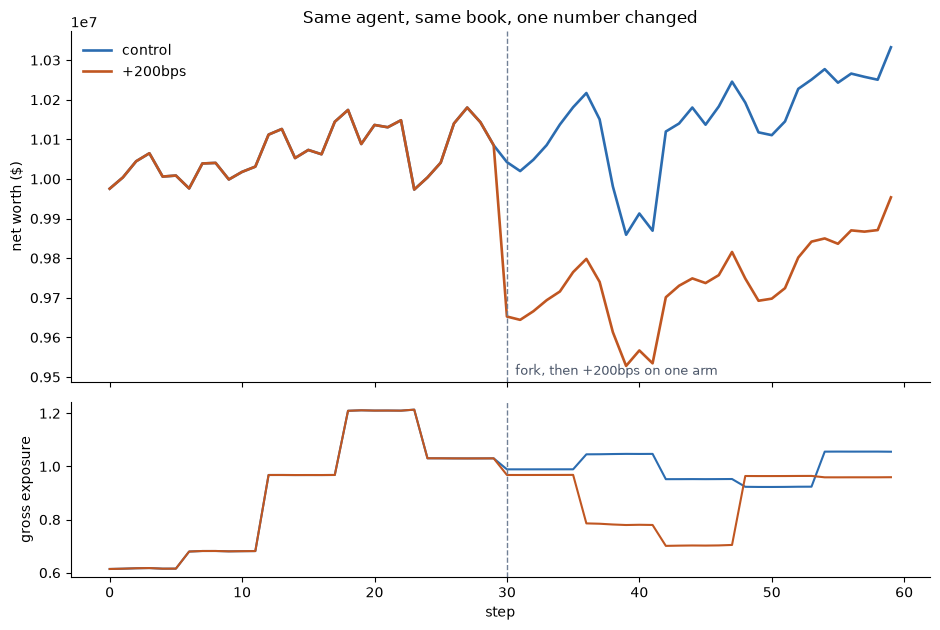

In [13]:
import matplotlib.pyplot as plt

# `World.trace` carries one row per STEP -- not per decision -- so this is
# the book as the market saw it, including the five steps a day on which the
# agent was not asked anything.
fork_step = control.fork_step

fig, (top, bottom) = plt.subplots(2, 1, figsize=(9.5, 6.4), sharex=True,
                                  gridspec_kw={"height_ratios": [2, 1]})
for label, w, colour in (("control", control, "#2b6cb0"),
                         ("+200bps", shock, "#c05621")):
    steps = [r["step"] for r in w.trace]
    top.plot(steps, [r["net_worth"] for r in w.trace],
             label=label, color=colour, lw=1.9)
    bottom.plot(steps, [r["exposure"] for r in w.trace],
                label=label, color=colour, lw=1.5)

for ax in (top, bottom):
    ax.axvline(fork_step, color="#718096", lw=1, ls="--")
    ax.spines[["top", "right"]].set_visible(False)
top.annotate("fork, then +200bps on one arm", xy=(fork_step, 0.02),
             xycoords=("data", "axes fraction"), xytext=(6, 0),
             textcoords="offset points", fontsize=9, color="#4a5568")
top.set_ylabel("net worth ($)")
top.legend(frameon=False, loc="upper left")
top.set_title("Same agent, same book, one number changed")
bottom.set_ylabel("gross exposure")
bottom.set_xlabel("step")
plt.tight_layout()
plt.show()

## 12. What the recording guarantees

The transcript is keyed by a digest of the **exact observation** the agent
was sent. Change the observation mapping and the key goes missing, and the
replay raises naming the step -- because replaying anyway would answer a new
question with an answer given to an old one.

What a key over the input cannot see is a change to something that never
enters it. The mandate reaches the agent as `run(instructions=...)`, not as
part of the prompt, so editing it would leave every recorded key intact --
every lookup would hit, the run would complete, and the decisions replayed
were taken under instructions nobody is running any more.

**That is a property of any adapter whose instructions travel separately from
the keyed input**, not a PydanticAI quirk, and the other integrations in this
package share it. The adapter refuses it by comparing the recorded
`instructions_digest` against the configured one -- and it does so when the
adapter is *built*, not at the first decision, because a replay that refuses
twenty simulated days in has already spent your time on a fault that was
knowable before the market opened.

In [14]:
# 1. A replay reproduces the recording exactly.
again = experiment.replay_agent(
    transcript=Transcript.load(experiment.FIXTURE), arm="shared")
twin = World(seed=experiment.SEED, universe=experiment.universe(),
             agent=again, cash=experiment.CASH, pins=experiment.PINS)
twin.run(days=experiment.SHARED_DAYS)
print("replay reproduces the shared history:",
      [e["decision"] for e in again.record]
      == [e["decision"] for e in agent.record[:len(again.record)]])

# 2. A replay under a different mandate is refused rather than answered.
from tradefloor.integrations.pydantic_ai import PydanticAIAdapter
from tradefloor.integrations.common import DecisionError

# The refusal happens when the ADAPTER IS BUILT, before any market runs, so
# the construction is what sits inside the try.
try:
    wrong = PydanticAIAdapter(mode="replay",
                              transcript=Transcript.load(experiment.FIXTURE),
                              instructions="Maximise turnover.",
                              every=experiment.DECISION_EVERY)
    World(seed=experiment.SEED, universe=experiment.universe(), agent=wrong,
          cash=experiment.CASH, pins=experiment.PINS).run(days=1)
    print("\nNOT REFUSED -- the guard is not doing its job")
except DecisionError as refused:
    print("\nrefused before the market opened, as it should be:\n")
    print(str(refused))

replay reproduces the shared history: True

refused before the market opened, as it should be:

this transcript was recorded under different instructions: the recording carries instructions_digest 631eee55bf7b9e99 and this adapter is configured with 759d5ba98db65bae (recorded under mandate version 2, configured with custom).
The replay key is a digest of the OBSERVATION, so every lookup would still hit and the run would complete -- answering the new instructions with decisions made under the old ones, which is a different experiment wearing this one's results.
Either pass the original mandate, `PydanticAIAdapter(..., instructions=<the recorded text>)`, or re-record the run live against the mandate you want.


---

### What this notebook is not

One seed, one agent, five decisions per arm after a shared five. It cannot
say the shocked arm was better or worse at investing, and it is not trying to: a single path through
a stochastic market is an anecdote with a scorecard attached.

What it *can* say is exactly what one agent, holding one book, did
differently when one number changed -- and that is a question no historical
dataset can answer, because there is no second history in which the rate held
still.

To run it live: `pip install "tradefloor[pydantic-ai]"`, set
`ANTHROPIC_API_KEY`, and set `TRADEFLOOR_LIVE_EXAMPLES=1` — the same opt-in
every integration example uses. To re-record the fixture, run the recorder in
the repository's scratchpad.